In [48]:
import pandas as pd
import re
from pprint import pprint
import numpy as np
from sqlalchemy import create_engine
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import folium
from constants.db_connections import ENGINE_READ_ONLY
from shapely.geometry import Point
import json

In [49]:
from constants import db_connections 

In [50]:
df = pd.read_sql("SELECT * FROM uploaded_data.field_sample t join uploaded_data.allowed_country_regions acr on lower(t.field_sample_country_region) = lower(acr.name) ", con=db_connections.ENGINE_READ_ONLY)  # columns: latitude, longitude, country

In [51]:
geodata = gpd.read_file(r"C:\Users\glj523\OneDrive - University of Copenhagen\Desktop\ne_10m_admin_0_countries_lakes\ne_10m_admin_0_countries_lakes.shp")
pdf = pd.DataFrame(geodata)
geodata = geodata[['NAME_LONG', 'ISO_A3', 'ISO_A2', 'geometry', 'GEOUNIT']]

In [52]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from shapely.geometry import Point

def match_coord_to_country(input_data, geodata, lat_col_name, lon_col_name, iso3_col_name, geodata_geometry_col_name="geometry", geodata_iso_col_name="ISO_A3"):
    # ---- Spatial Join with Countries ----
    geometry = [Point(xy) for xy in zip(input_data[lon_col_name], input_data[lat_col_name])]
    input_gdf = gpd.GeoDataFrame(input_data, geometry=geometry, crs="EPSG:4326")
    joined = gpd.sjoin(input_gdf, geodata[[geodata_geometry_col_name, geodata_iso_col_name]], how="left", predicate='intersects')
    input_data["Detected_Country"] = None
    input_data.loc[joined.index, "Detected_Country"] = joined[geodata_iso_col_name].values
    
    # ---- Country Match Classification ----
    def classify_match(row):
        if pd.isna(row[iso3_col_name]) or pd.isna(row["Detected_Country"]):
            return "Unknown"
        return "Correct" if row[iso3_col_name].lower() == row["Detected_Country"].lower() else "Wrong"
    input_data["Country_Match"] = input_data.apply(classify_match, axis=1)
    # ---- Static Map ----
    map_data = input_data[input_data[lat_col_name].between(-90, 90) & input_data[lon_col_name].between(-180, 180)].copy()
    geometry = [Point(xy) for xy in zip(map_data[lon_col_name], map_data[lat_col_name])]
    map_gdf = gpd.GeoDataFrame(map_data, geometry=geometry, crs="EPSG:4326")
    fig, ax = plt.subplots(figsize=(12, 8))
    geodata.plot(ax=ax, color='white', edgecolor='gray')
    colors = map_gdf["Country_Match"].map({"Correct": "black", "Wrong": "red"}).fillna("gray")
    map_gdf.plot(ax=ax, color=colors, markersize=10)
    plt.title("Country Match: Correct vs Wrong")
    plt.show()
    # ---- Interactive Map ----
    m = folium.Map(zoom_start=2)
    colors = {"Correct": "black", "Wrong": "red", "Unknown": "blue"}
    for _, row in map_gdf.iterrows():
        folium.CircleMarker(
            location=(row[lat_col_name], row[lon_col_name]),
            radius=4,
            color=colors.get(row["Country_Match"], "gray"),
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(f"""
            <b>Site:</b> {row.get('Site', '')}<br>
            <b>Country:</b> {row.get('Country', '')}<br>
            <b>Detected:</b> {row.get('Detected_Country', '')}<br>
            <b>Status:</b> {row.get('Country_Match', '')}
            """, max_width=250)
        ).add_to(m)
    legend_html = """
    <div style="position: fixed; bottom: 50px; left: 50px; width: 150px; background: white; border:1px solid grey; padding: 10px;">
    <b>Country Match</b><br>
    <i style="color:black">●</i> Correct<br>
    <i style="color:red">●</i> Wrong<br>
    <i style="color:blue">●</i> Unknown
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))

    return input_data, m

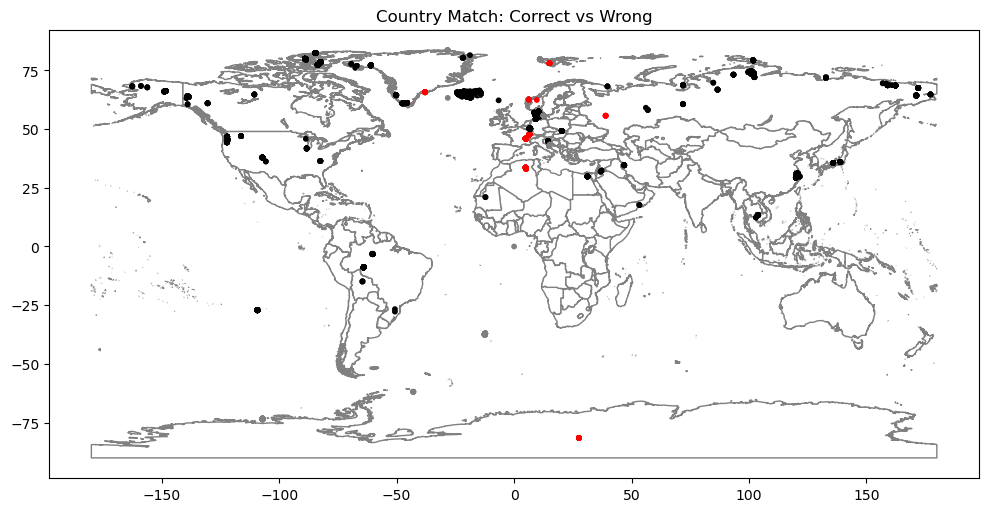

In [53]:
df, m = match_coord_to_country(df, geodata, "latitude", "longitude", 'iso_3166_1_alpha3')

In [84]:
mask = (df['Country_Match'] == 'Unknown') 

In [85]:
unknown = df[mask]

In [86]:
mask = unknown['field_sample_site_name'] == "Grotta"

In [87]:
unknown = unknown[mask]

In [88]:
mask = (df['Country_Match'] == 'Wrong')
wrong = df[mask]

In [89]:
wrong

,field_sample_id,field_sample_country_region,field_sample_site_name,latitude,longitude,field_sample_sample_date,field_sample_sample_provider,field_sample_running_project_title,field_sampling_depth_discrete,field_sampling_interval_to,...,field_sample_parent_id,field_sample_age_estimate_unit,geographical_location_names,owned_by_aegis,storage_id,name,iso_3166_1_alpha2,iso_3166_1_alpha3,Detected_Country,Country_Match
1038,CGG_3_000064,Denmark,LC,61.139900,-45.534700,2024-10-08,Yucheng Wang,Permafrost,NaN,NaN,...,None,ka BP,Denmark,unknown,None,Denmark,DK,DNK,GRL,Wrong
1039,CGG_3_000066,Denmark,LC,61.139900,-45.534700,2024-10-08,Yucheng Wang,Permafrost,NaN,NaN,...,None,ka BP,Denmark,unknown,None,Denmark,DK,DNK,GRL,Wrong
1040,CGG_3_000067,Denmark,LC,61.139900,-45.534700,2024-10-08,Yucheng Wang,Permafrost,NaN,NaN,...,None,ka BP,Denmark,unknown,None,Denmark,DK,DNK,GRL,Wrong
1054,CGG_3_002068,Denmark,LS,65.683333,-37.916667,2024-10-08,Yucheng Wang,Permafrost,NaN,NaN,...,None,ka BP,Denmark,unknown,None,Denmark,DK,DNK,GRL,Wrong
1056,CGG_3_002094,Denmark,LS,65.683333,-37.916667,2024-10-08,Yucheng Wang,Permafrost,NaN,NaN,...,None,ka BP,Denmark,unknown,None,Denmark,DK,DNK,GRL,Wrong
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,US24_Lake_Tulane_4A_10L,USA,Lake Tulane,-81.503841,27.587303,2024-06-07,Mikkel Winther Pedersen,Pleistocene megafaunal extinctions,NaN,NaN,...,None,ka BP,USA,unknown,None,USA,US,USA,ATA,Wrong
2638,US24_Lake_Tulane_4A_12L,USA,Lake Tulane,-81.503841,27.587303,2024-06-07,Mikkel Winther Pedersen,Pleistocene megafaunal extinctions,NaN,NaN,...,None,ka BP,USA,unknown,None,USA,US,USA,ATA,Wrong
2677,US24_Lake_Tulane_7A_3B,USA,Lake Tulane,-81.503841,27.587303,2024-06-07,Mikkel Winther Pedersen,Pleistocene megafaunal extinctions,NaN,NaN,...,None,ka BP,USA,unknown,None,USA,US,USA,ATA,Wrong
2687,US24_Lake_Tulane_4A_4L,USA,Lake Tulane,-81.503841,27.587303,2024-06-07,Mikkel Winther Pedersen,Pleistocene megafaunal extinctions,NaN,NaN,...,None,ka BP,USA,unknown,None,USA,US,USA,ATA,Wrong


In [90]:
mask = ~wrong['field_sample_country_region'].isin(['France', 'Norway'])

In [91]:
wrong = wrong[mask]

In [93]:
bad_geo = pd.concat([unknown, wrong], ignore_index=True)

In [97]:
bad_geo.columns

Index(['field_sample_id', 'field_sample_country_region',
       'field_sample_site_name', 'latitude', 'longitude',
       'field_sample_sample_date', 'field_sample_sample_provider',
       'field_sample_running_project_title', 'field_sampling_depth_discrete',
       'field_sampling_interval_to', 'field_sample_water_depth',
       'field_sample_container', 'field_sample_environment',
       'field_sample_context', 'field_sample_age_estimate_oldest',
       'field_sample_elevation', 'field_sample_storage_address',
       'field_sample_storage_setting', 'field_sample_storage_location',
       'miscellaneous_field_sample_measurements_or_observations',
       'miscellaneous_environmental_field_measurements_or_observations',
       'links_to_field_sample_related_images',
       'links_to_other_relevant_field_sample_information',
       'field_sample_comments', 'database_insert_by', 'upload_sheet',
       'database_insert_datetime_utc', 'upload_uuid',
       'field_sampling_interval_from', 'f

In [101]:
bad_geo["field_sample_pi"].unique()

array(['Kurt Henrik Kjær', 'Eske Willerslev', 'Anthony Ruter',
       'Mikkel Winther Pedersen'], dtype=object)

In [99]:
bad_geo["field_sample_sample_provider"].unique()

array(['Wesley R. Farnsworth', 'Yucheng Wang', 'Simone Fabienne Mayer',
       'Mikkel Winther Pedersen'], dtype=object)

In [103]:
wes = bad_geo[bad_geo['field_sample_sample_provider'] == 'Wesley R. Farnsworth']
yus = bad_geo[bad_geo['field_sample_sample_provider'] == 'Yucheng Wang']
sim = bad_geo[bad_geo['field_sample_sample_provider'] == 'Simone Fabienne Mayer']
mwp = bad_geo[bad_geo['field_sample_sample_provider'] == 'Mikkel Winther Pedersen']

In [108]:
yus.to_csv(r"C:\Users\glj523\OneDrive - University of Copenhagen\Desktop\bad_geolocation_YW.csv", index=False)
mwp.to_csv(r"C:\Users\glj523\OneDrive - University of Copenhagen\Desktop\bad_geolocation_MWP.csv", index=False)
wes.to_csv(r"C:\Users\glj523\OneDrive - University of Copenhagen\Desktop\bad_geolocation_WRF.csv", index=False)


In [65]:
# pip install plotly pandas

import plotly.express as px


fig = px.scatter_map(
    unknown_df,
    lat="latitude",
    lon="longitude",
    hover_name="field_sample_id",
    hover_data={
        "field_sample_country_region": True,
        "field_sample_site_name": True,
            "Detected_Country": True
    },
    zoom=6,
    height=600
)
fig.update_layout(map_style="open-street-map")  # no Mapbox token needed
fig.show()